In [ ]:
import os
import numpy as np
import plotly.graph_objects as go

# --- Updated signal function ---
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

# --- Wrapper function ---
def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# --- Custom Plotly Template ---
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}
power = 8

# --- Base path ---
base_path = rf"C:\Users\Atanu\OneDrive\Desktop\research_work\paper\T1_atanu_github\T1_measurements\codes\data\2025\May_12\arranging_datas_with_power\{power}uW"


# --- Power folders ---
power_folders = ['l_15.0us', 'l_25.0us', 'l_50.0us', 'l_100.0us']

# --- Initialize figure ---
fig = go.Figure()

# --- Process each power folder ---
for folder in power_folders:
    folder_path = os.path.join(base_path, folder)
    npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    
    if len(npz_files) < 3:
        print(f"Less than 3 datasets found in {folder_path}. Skipping.")
        continue

    signal_photon_list = []
    time_axis = None
    

    for npz_file in npz_files[:-1]:  # Limit to 3 datasets
        npz_path = os.path.join(folder_path, npz_file)
        data = dict(np.load(npz_path))
        time_axis, signal_photon, _, _ = data_to_time_signal(data, 2000, first='signal')
        signal_photon_list.append(signal_photon[1:])  # skip the first element

    # Convert list to 2D array (shape: 3 x N)
    signal_array = np.vstack(signal_photon_list)

    # Calculate mean and std deviation
    mean_signal = np.mean(signal_array, axis=0)
    std_signal = np.std(signal_array, axis=0)

    fig.add_trace(go.Scatter(
        x=time_axis[1:],  # skip the first point
        y=mean_signal,
        mode='markers',
        name=f'{folder}',
        error_y=dict(
            type='data',
            array=std_signal,
            visible=True
        )
    ))

# --- Final layout ---
fig.update_layout(
    template=fig_template,
    title=f'Signal Photon vs Time for {power}uW Initialization',
    xaxis_title='Time',
    yaxis_title='Counts (T<sub>1</sub>)'
)

# --- Show and Save ---
fig.show()

html_output_path = os.path.join(base_path, f"signal_vs_time_plot_with_errorbars_{power}uW.html")
fig.write_html(html_output_path)
print(f"Plot successfully saved to: {html_output_path}")


In [ ]:
import os
import numpy as np
import plotly.graph_objects as go

# --- Signal Processing Function ---
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

# --- Wrapper to Process NPZ ---
def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# --- Plotly Template ---
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

# --- Calibration Dictionary (source mW → sample µW) ---
calibration = {
    1: 13,
    3: 36,
    4: 47,
    5: 64,
    7: 79,
    9: 104,
    11: 139,
    13: 167,
    15: 191,
    17: 209,
    18: 221
}

# --- Parameters ---
samples = 2000
base_folder_root = r"C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10"
pulse_folder = "l_50.0us"
systematic_path = r"systematic\a_5\s_2000"
cluster_folders = ['first cluster', 'second cluster', 'third cluster', 'fourth cluster', 'fifth cluster']
power_folders = ['p_11mW', 'p_3mW']

# --- Loop through each cluster ---
for cluster_name in cluster_folders:
    print(f"\nProcessing: {cluster_name}")
    
    # --- Initialize a new figure for each cluster ---
    fig = go.Figure()

    for power_folder in power_folders:
        # Extract numeric source power (e.g., "11" from "p_11mW")
        try:
            source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
        except (IndexError, ValueError):
            print(f"Could not extract power from folder name: {power_folder}")
            continue

        # Convert to sample power using calibration
        sample_power_uW = calibration.get(source_power_mW, None)
        if sample_power_uW is None:
            print(f"No calibration available for {source_power_mW} mW. Skipping.")
            continue

        # Construct full path
        cluster_path = os.path.join(base_folder_root, cluster_name)
        folder_path = os.path.join(cluster_path, power_folder, pulse_folder, systematic_path)
        if not os.path.exists(folder_path):
            print(f"Folder does not exist: {folder_path}")
            continue

        # Load NPZ files
        npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
        if len(npz_files) < 3:
            print(f"Less than 3 datasets found in {folder_path}. Skipping.")
            continue

        signal_photon_list = []
        time_axis = None

        for npz_file in npz_files[:3]:
            npz_path = os.path.join(folder_path, npz_file)
            data = dict(np.load(npz_path))
            time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
            signal_photon_list.append(signal_photon[1:])  # Skip first point

        signal_array = np.vstack(signal_photon_list)
        mean_signal = np.mean(signal_array, axis=0)
        std_signal = np.std(signal_array, axis=0)

        fig.add_trace(go.Scatter(
            x=time_axis[1:],  # Skip first point
            y=mean_signal,
            mode='markers+lines',
            name=f'{sample_power_uW} µW',
            error_y=dict(
                type='data',
                array=std_signal,
                visible=True
            )
        ))

    # --- Final Plot Layout ---
    fig.update_layout(
        template=fig_template,
        xaxis_title='Time (ns)',
        yaxis_title='Sig/Ref Counts (arb. unit)',
        legend_title='Sample Plane Power',
        title=f"T₁ Measurement — {cluster_name.title()}",
        width=800,
        height=600
    )

    # --- Show Plot ---
    fig.show()

    # --- Save HTML ---
    filename_suffix = "_".join([
        f"{calibration[int(p.split('_')[1].replace('mW', ''))]}uW"
        for p in power_folders
        if int(p.split('_')[1].replace('mW', '')) in calibration
    ])
    safe_cluster_name = cluster_name.replace(" ", "_").lower()
    output_path = os.path.join(base_folder_root, cluster_name, f"t1_plot_{safe_cluster_name}_{filename_suffix}.html")
    fig.write_html(output_path)
    print(f"Plot saved to: {output_path}")

In [ ]:
# --- Parameters ---
samples = 2000
base_path = r"D:\Atanu\Atanu_Github\T1_measurements\codes\data\2025\Oct_10\first cluster"
pulse_folder = 'l_50.0us'
systematic_path = r"systematic\a_5\s_2000"

# --- Power folders to process ---
power_folders = ['p_3mW', 'p_4mW', 'p_5mW', 'p_9mW', 'p_11mW', 'p_18mW']

# --- Initialize figure ---
fig = go.Figure()

# --- Loop over power folders ---
for power_folder in power_folders:
    try:
        source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
    except (IndexError, ValueError):
        print(f"Could not parse power from folder: {power_folder}")
        continue

    sample_power_uW = calibration.get(source_power_mW, None)
    if sample_power_uW is None:
        print(f"[⚠️] No calibration for {source_power_mW} mW — Skipping.")
        continue

    folder_path = os.path.join(base_path, power_folder, pulse_folder, systematic_path)
    if not os.path.exists(folder_path):
        print(f"[❌] Folder not found: {folder_path}")
        continue

    npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    if len(npz_files) < 3:
        print(f"[⚠️] Less than 3 datasets in {folder_path}. Skipping.")
        continue

    signal_photon_list = []
    time_axis = None

    for npz_file in npz_files[:3]:
        npz_path = os.path.join(folder_path, npz_file)
        data = dict(np.load(npz_path))
        time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
        signal_photon_list.append(signal_photon[1:])  # Skip first point

    signal_array = np.vstack(signal_photon_list)
    mean_signal = np.mean(signal_array, axis=0)
    std_signal = np.std(signal_array, axis=0)

    fig.add_trace(go.Scatter(
        x=time_axis[1:],  # Skip first point
        y=mean_signal,
        mode='markers+lines',
        name=f'{sample_power_uW} µW',
        error_y=dict(
            type='data',
            array=std_signal,
            visible=True
        )
    ))

# --- Final layout ---
fig.update_layout(
    template=fig_template,
    title='T₁ Measurement — First Cluster (Various Powers)',
    xaxis_title='Time (ns)',
    yaxis_title='Sig/Ref Counts (arb. unit)',
    legend_title='Sample Plane Power',
    height = 600,
    width = 800
)

# --- Show and Save ---
fig.show()

# --- Save as HTML ---
valid_powers = [
    f"{calibration[int(p.split('_')[1].replace('mW', ''))]}uW"
    for p in power_folders
    if int(p.split('_')[1].replace('mW', '')) in calibration
]

filename_suffix = "_".join(valid_powers)
output_path = os.path.join(base_path, f"t1_plot_first_cluster_{filename_suffix}.html")
fig.write_html(output_path)
print(f"Plot saved to: {output_path}")

In [ ]:
# --- Parameters ---
samples = 2000
root_base = r"C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid"
mol_levels = ['1 mol', '0.1 mol']
cluster_types = ['small cluster', 'big cluster', 'bigger cluster']
power_folders = ['p_11mW', 'p_3mW']
pulse_folder = 'l_50.0us'
systematic_path = r"systematic\a_5\s_2000"

# --- Loop through each molarity and cluster ---
for mol in mol_levels:
    for cluster in cluster_types:
        print(f"\nProcessing: {mol} → {cluster}")

        fig = go.Figure()

        for power_folder in power_folders:
            try:
                source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
            except (IndexError, ValueError):
                print(f"Could not extract power from: {power_folder}")
                continue

            sample_power_uW = calibration.get(source_power_mW, None)
            if sample_power_uW is None:
                print(f"No calibration available for {source_power_mW} mW. Skipping.")
                continue

            # Build full path
            cluster_path = os.path.join(root_base, mol, cluster)
            data_path = os.path.join(cluster_path, power_folder, pulse_folder, systematic_path)

            if not os.path.exists(data_path):
                print(f"Path not found: {data_path}")
                continue

            # Load .npz files
            npz_files = sorted([f for f in os.listdir(data_path) if f.endswith('.npz')])
            if len(npz_files) < 3:
                print(f"Less than 3 datasets found in {data_path}. Skipping.")
                continue

            signal_photon_list = []
            time_axis = None

            for npz_file in npz_files[:3]:
                file_path = os.path.join(data_path, npz_file)
                data = dict(np.load(file_path))
                time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
                signal_photon_list.append(signal_photon[1:])  # Skip first point

            signal_array = np.vstack(signal_photon_list)
            mean_signal = np.mean(signal_array, axis=0)
            std_signal = np.std(signal_array, axis=0)

            fig.add_trace(go.Scatter(
                x=time_axis[1:],  # Skip first point
                y=mean_signal,
                mode='markers+lines',
                name=f'{sample_power_uW} µW',
                error_y=dict(
                    type='data',
                    array=std_signal,
                    visible=True
                )
            ))

        # Final layout
        fig.update_layout(
            template=fig_template,
            title=f"T₁ Measurement — {mol}, {cluster.title()}",
            xaxis_title='Time (ns)',
            yaxis_title='Sig/Ref Counts (arb. unit)',
            legend_title='Sample Plane Power',
            height = 600,
            width = 800,
        )

        fig.show()

        # Save
        filename_suffix = "_".join([
            f"{calibration[int(p.split('_')[1].replace('mW', ''))]}uW"
            for p in power_folders
            if int(p.split('_')[1].replace('mW', '')) in calibration
        ])
        safe_cluster = cluster.replace(" ", "_").lower()
        safe_mol = mol.replace(" ", "_").lower()
        output_path = os.path.join(cluster_path, f"t1_plot_{safe_mol}_{safe_cluster}_{filename_suffix}.html")
        fig.write_html(output_path)
        print(f"Saved: {output_path}")

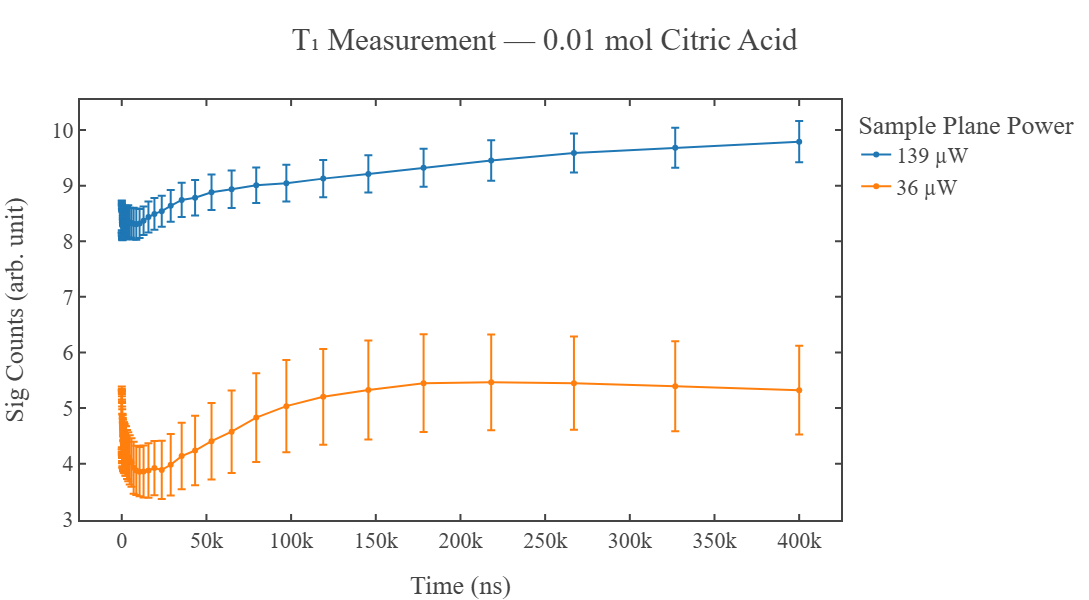

Plot saved to: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\0.01 mol\t1_plot_0.01mol_139uW_36uW_sig.html


In [59]:
# --- Parameters ---
samples = 2000
base_path = r"C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\0.01 mol"
power_folders = ['p_11mW', 'p_3mW']
pulse_folder = 'l_50.0us'
systematic_path = r"systematic\a_5\s_2000"

# --- Initialize Plot ---
fig = go.Figure()

# --- Process each power ---
for power_folder in power_folders:
    try:
        source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
    except (IndexError, ValueError):
        print(f"Could not extract power from: {power_folder}")
        continue

    sample_power_uW = calibration.get(source_power_mW, None)
    if sample_power_uW is None:
        print(f"No calibration available for {source_power_mW} mW. Skipping.")
        continue

    folder_path = os.path.join(base_path, power_folder, pulse_folder, systematic_path)
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    if len(npz_files) < 3:
        print(f"Less than 3 datasets found in {folder_path}. Skipping.")
        continue

    signal_photon_list = []
    time_axis = None

    for npz_file in npz_files[:3]:
        npz_path = os.path.join(folder_path, npz_file)
        data = dict(np.load(npz_path))
        time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
        signal_photon_list.append(signal_photon[1:])  # Skip first point

    signal_array = np.vstack(signal_photon_list)
    mean_signal = np.mean(signal_array, axis=0)
    std_signal = np.std(signal_array, axis=0)

    fig.add_trace(go.Scatter(
        x=time_axis[1:],
        y=mean_signal,
        mode='markers+lines',
        name=f'{sample_power_uW} µW',
        error_y=dict(
            type='data',
            array=std_signal,
            visible=True
        )
    ))

# --- Final Layout ---
fig.update_layout(
    template=fig_template,
    title='T₁ Measurement — 0.01 mol Citric Acid',
    xaxis_title='Time (ns)',
    yaxis_title='Sig/Ref Counts (arb. unit)',
    legend_title='Sample Plane Power',
    height = 600,
    width = 800,
)

# --- Show and Save ---
fig.show()

# Save plot
filename_suffix = "_".join([
    f"{calibration[int(p.split('_')[1].replace('mW', ''))]}uW"
    for p in power_folders
    if int(p.split('_')[1].replace('mW', '')) in calibration
])
output_path = os.path.join(base_path, f"t1_plot_0.01mol_{filename_suffix}.html")
fig.write_html(output_path)
print(f"Plot saved to: {output_path}")

### first cluster power dependency

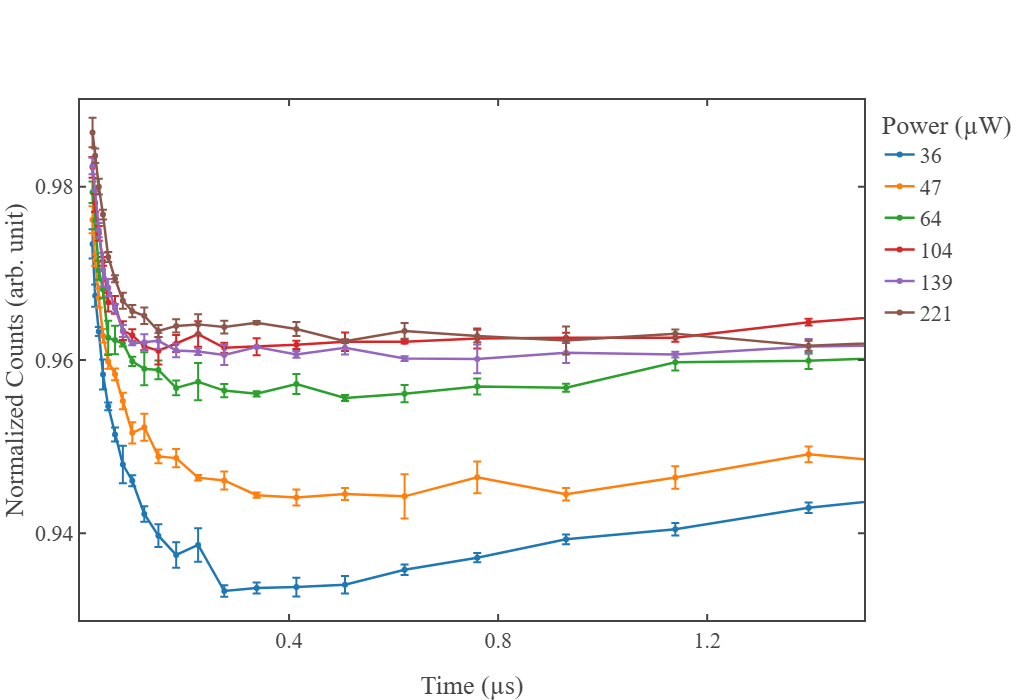

Saved figure: D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper\First_cluster_power_dependency_zoomed_in.png


In [38]:
import os
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio  # Required for saving as PNG

# ============================================================
# --- Signal Processing Functions ---
# ============================================================
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# ============================================================
# --- Plotly Template & Calibration ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

# --- Calibration Dictionary (source mW → sample µW) ---
calibration = {
    1: 13,
    3: 36,
    4: 47,
    5: 64,
    7: 79,
    9: 104,
    11: 139,
    13: 167,
    15: 191,
    17: 209,
    18: 221
}

# ============================================================
# --- Parameters ---
# ============================================================
samples = 2000
base_path = r"D:\Atanu\Atanu_Github\T1_measurements\codes\data\2025\Oct_10\first cluster"
pulse_folder = 'l_50.0us'
systematic_path = r"systematic\a_5\s_2000"

# --- Power folders to process ---
power_folders = ['p_3mW', 'p_4mW', 'p_5mW', 'p_9mW', 'p_11mW', 'p_18mW']

# --- Define Consistent Colors ---
# These ensure colors stay locked to specific powers across different plots
color_map = {
    'p_3mW': '#1f77b4',  # Muted Blue
    'p_4mW': '#ff7f0e',  # Safety Orange
    'p_5mW': '#2ca02c',  # Cooked Asparagus Green
    'p_9mW': '#d62728',  # Brick Red
    'p_11mW': '#9467bd', # Muted Purple
    'p_18mW': '#8c564b'  # Chestnut Brown
}

# ============================================================
# --- Data Processing & Plotting ---
# ============================================================
fig = go.Figure()

for power_folder in power_folders:
    try:
        source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
    except (IndexError, ValueError):
        print(f"Could not parse power from folder: {power_folder}")
        continue

    sample_power_uW = calibration.get(source_power_mW, None)
    if sample_power_uW is None:
        print(f"[⚠️] No calibration for {source_power_mW} mW — Skipping.")
        continue

    folder_path = os.path.join(base_path, power_folder, pulse_folder, systematic_path)
    if not os.path.exists(folder_path):
        print(f"[❌] Folder not found: {folder_path}")
        continue

    npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    if len(npz_files) < 3:
        print(f"[⚠️] Less than 3 datasets in {folder_path}. Skipping.")
        continue

    signal_photon_list = []
    time_axis = None

    for npz_file in npz_files[:3]:
        npz_path = os.path.join(folder_path, npz_file)
        data = dict(np.load(npz_path))
        time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
        signal_photon_list.append(signal_photon[1:])  # Skip first point

    signal_array = np.vstack(signal_photon_list)
    mean_signal = np.mean(signal_array, axis=0)
    std_signal = np.std(signal_array, axis=0)
    
    # Grab the fixed color for this specific power (defaults to black if not found)
    trace_color = color_map.get(power_folder, '#000000')

    fig.add_trace(go.Scatter(
        x=time_axis[1:]/1e3,  # Skip first point
        y=mean_signal,
        mode='markers+lines',
        name=f'{sample_power_uW}',
        line=dict(width=2.5,color=trace_color),
        marker=dict(size=6, color=trace_color),
        error_y=dict(
            type='data',
            array=std_signal,
            visible=True,
            color=trace_color
        )
    ))

# --- Final layout ---
fig.update_layout(
    template=fig_template,
    # title='T₁ Measurement — First Cluster (Various Powers)',
    xaxis_title='Time (µs)',
    yaxis_title='Normalized Counts (arb. unit)',
    legend_title='Power (µW)',
    height=700,
    width=800, 


    xaxis=dict(
        range=[-10, 410],
        tickvals=[0,100,200,300,400],
        # range=[0, 1.5],
        # tickvals=[0.4,0.8,1.2],
    ),  
    yaxis=dict(
                range=[0.65, 1.05],
                tickvals=[0.7, 0.8, 0.9, 1.0],
               # range=[0.93, 0.99],
               # tickvals=[0.94,0.96,0.98],
              )
)

# --- Show ---
fig.show()

# ============================================================
# --- Save figure ---
# ============================================================
output_fig_folder = r"D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper"
os.makedirs(output_fig_folder, exist_ok=True)

out_path = os.path.join(output_fig_folder, "First_cluster_power_dependency.png")
# out_path = os.path.join(output_fig_folder, "First_cluster_power_dependency_zoomed_in.png")

pio.write_image(
    fig, 
    out_path, 
    width=800,   # Base width in pixels
    height=700,  # Base height in pixels
    scale=4      # Multiplies base dimensions (Final image: 3200 x 2400)
)

print("Saved figure:", out_path)


Processing: first cluster


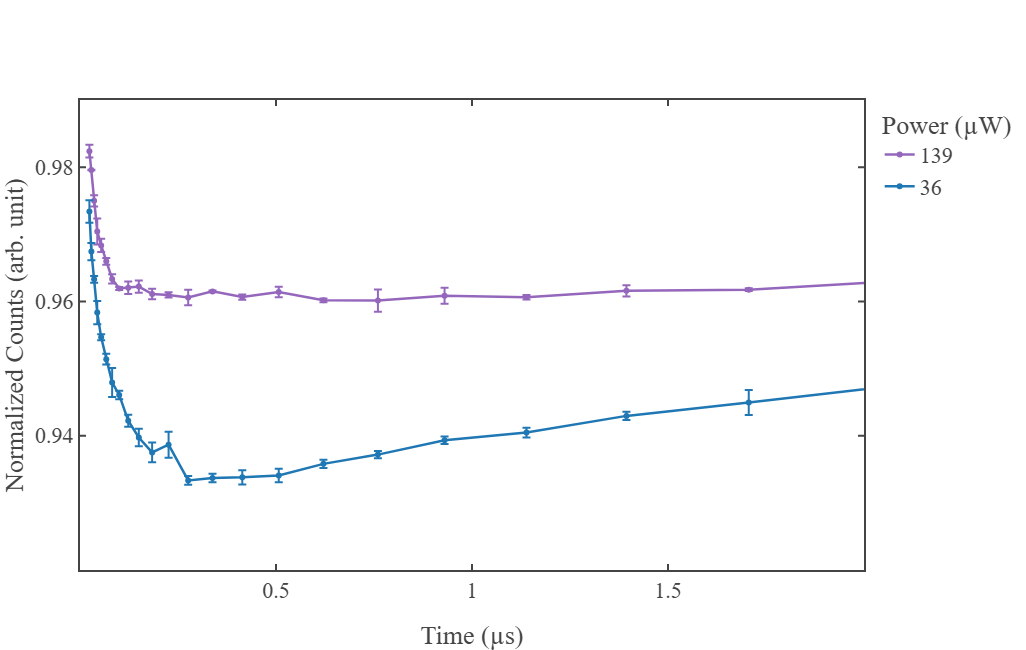


Processing: second cluster


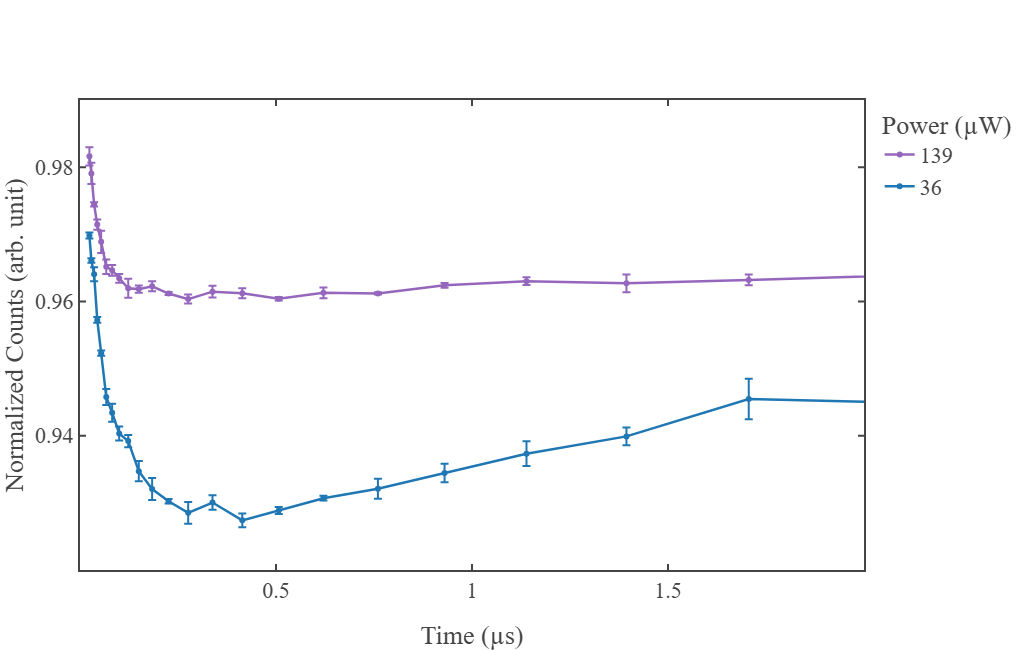


Processing: third cluster


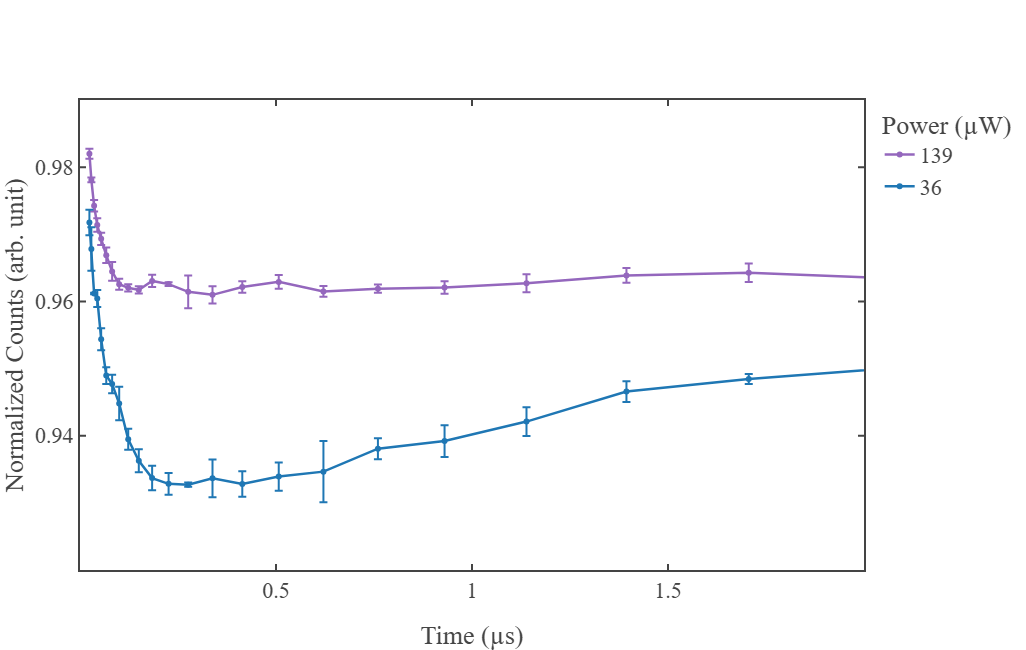


Processing: fourth cluster


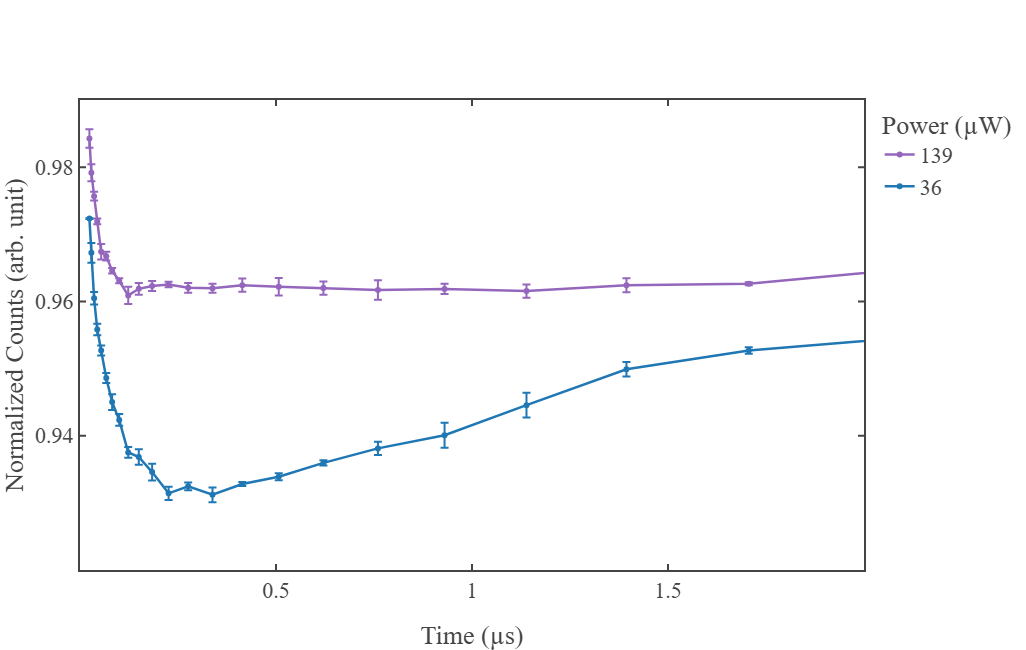


Processing: fifth cluster


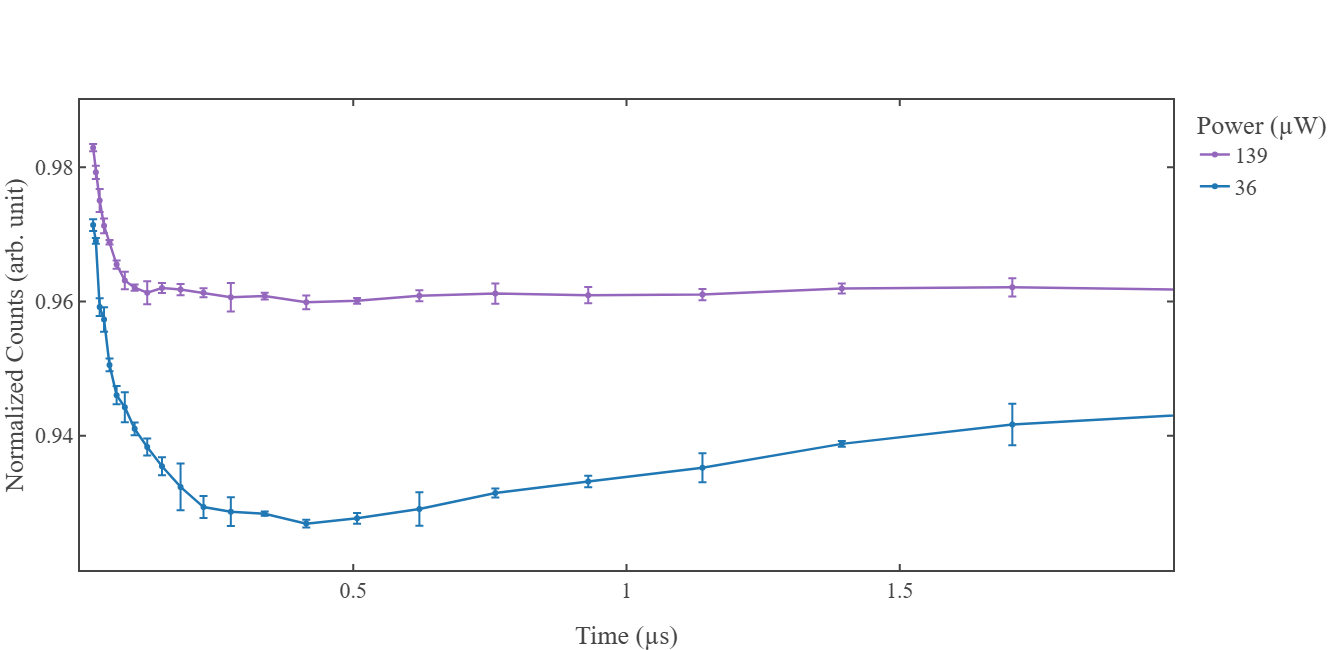

In [8]:
import os
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio # Required for saving as PNG

# ============================================================
# --- Signal Processing Functions ---
# ============================================================
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# ============================================================
# --- Plotly Template & Calibration ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

# --- Calibration Dictionary (source mW → sample µW) ---
calibration = {
    1: 13,
    3: 36,
    4: 47,
    5: 64,
    7: 79,
    9: 104,
    11: 139,
    13: 167,
    15: 191,
    17: 209,
    18: 221
}

# ============================================================
# --- Paths and Parameters ---
# ============================================================
samples = 2000
base_folder_root = r"D:\Atanu\Atanu_Github\T1_measurements\codes\data\2025\Oct_10"
pulse_folder = "l_50.0us"
systematic_path = r"systematic\a_5\s_2000"
cluster_folders = ['first cluster', 'second cluster', 'third cluster', 'fourth cluster', 'fifth cluster']
power_folders = ['p_11mW', 'p_3mW']

# --- Define Output Folder ---
output_fig_folder = r"D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper"
os.makedirs(output_fig_folder, exist_ok=True)

# --- Define Consistent Colors ---
color_map = {
    'p_3mW': '#1f77b4',  # Muted Blue
    'p_4mW': '#ff7f0e',  # Safety Orange
    'p_5mW': '#2ca02c',  # Cooked Asparagus Green
    'p_9mW': '#d62728',  # Brick Red
    'p_11mW': '#9467bd', # Muted Purple
    'p_18mW': '#8c564b'  # Chestnut Brown
}

# ============================================================
# --- Data Processing & Plotting Loop ---
# ============================================================
for cluster_name in cluster_folders:
    print(f"\nProcessing: {cluster_name}")
    
    # --- Initialize a new figure for each cluster ---
    fig = go.Figure()

    for power_folder in power_folders:
        try:
            source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
        except (IndexError, ValueError):
            print(f"Could not extract power from folder name: {power_folder}")
            continue

        sample_power_uW = calibration.get(source_power_mW, None)
        if sample_power_uW is None:
            print(f"No calibration available for {source_power_mW} mW. Skipping.")
            continue

        cluster_path = os.path.join(base_folder_root, cluster_name)
        folder_path = os.path.join(cluster_path, power_folder, pulse_folder, systematic_path)
        if not os.path.exists(folder_path):
            print(f"Folder does not exist: {folder_path}")
            continue

        npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
        if len(npz_files) < 3:
            print(f"Less than 3 datasets found in {folder_path}. Skipping.")
            continue

        signal_photon_list = []
        time_axis = None

        for npz_file in npz_files[:3]:
            npz_path = os.path.join(folder_path, npz_file)
            data = dict(np.load(npz_path))
            time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
            signal_photon_list.append(signal_photon[1:])  # Skip first point

        signal_array = np.vstack(signal_photon_list)
        mean_signal = np.mean(signal_array, axis=0)
        std_signal = np.std(signal_array, axis=0)

        trace_color = color_map.get(power_folder, '#000000')

        fig.add_trace(go.Scatter(
            x=time_axis[1:] / 1e3,  # Skip first point and convert to µs
            y=mean_signal,
            mode='markers+lines',
            name=f'{sample_power_uW}',
            line=dict(width=2.5, color=trace_color),
            marker=dict(size=6, color=trace_color),
            error_y=dict(
                type='data',
                array=std_signal,
                visible=True,
                color=trace_color
            )
        ))

    # --- Final Plot Layout ---
    fig.update_layout(
        template=fig_template,
        # title=f"T₁ Measurement — {cluster_name.title()}", # Commented out to match your preference
        xaxis_title='Time (µs)',
        yaxis_title='Normalized Counts (arb. unit)',
        legend_title='Power (µW)',
        width=800,
        height=650,
        xaxis=dict(
            # range=[-10, 410],
            # tickvals=[0, 100, 200, 300, 400],
            range=[0, 2.0],
            tickvals=[0.5,1.0,1.5],
        ),  
        yaxis=dict(
            # range=[0.79, 1.02],
            # tickvals=[ 0.8, 0.9,1.0],
            range=[0.92, 0.99],
            tickvals=[0.94,0.96,0.98],
              
        )
    )

    # --- Show Plot ---
    fig.show()

    # # --- Save High-Resolution PNG ---
    # safe_cluster_name = cluster_name.replace(" ", "_").lower()
    # out_path = os.path.join(output_fig_folder, f"{safe_cluster_name}_power_dependency.png")
    
    # pio.write_image(
    #     fig, 
    #     out_path, 
    #     width=800, 
    #     height=650, 
    #     scale=4
    # )
    # print(f"Saved figure: {out_path}")


Processing Power: p_11mW

Processing Power: p_3mW


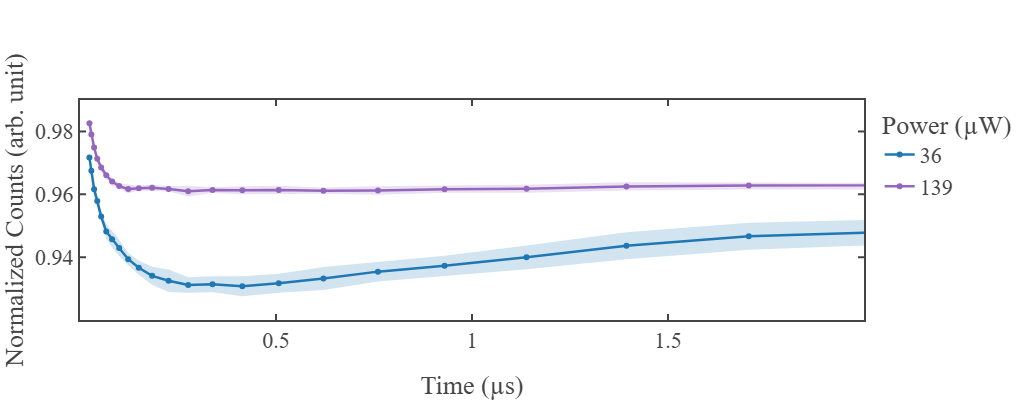

Saved grand average figure: D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper\grand_average_power_dependency.png


In [11]:
import os
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio # Required for saving as PNG

# ============================================================
# --- Helper Functions ---
# ============================================================
def hex_to_rgba(hex_color, alpha=0.2):
    """Converts a hex color string to an rgba string with specified opacity."""
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r}, {g}, {b}, {alpha})'

# ============================================================
# --- Signal Processing Functions ---
# ============================================================
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# ============================================================
# --- Plotly Template & Calibration ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

# --- Calibration Dictionary (source mW → sample µW) ---
calibration = {
    1: 13,
    3: 36,   # Corresponds to p_3mW
    4: 47,
    5: 64,
    7: 79,
    9: 104,
    11: 139, # Corresponds to p_11mW
    13: 167,
    15: 191,
    17: 209,
    18: 221
}

# ============================================================
# --- Paths and Parameters ---
# ============================================================
samples = 2000
base_folder_root = r"D:\Atanu\Atanu_Github\T1_measurements\codes\data\2025\Oct_10"
pulse_folder = "l_50.0us"
systematic_path = r"systematic\a_5\s_2000"
cluster_folders = ['first cluster', 'second cluster', 'third cluster', 'fourth cluster', 'fifth cluster']
power_folders = ['p_11mW', 'p_3mW'] # 139 µW and 36 µW

# --- Define Output Folder ---
output_fig_folder = r"D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper"
os.makedirs(output_fig_folder, exist_ok=True)

# --- Define Consistent Colors ---
color_map = {
    'p_3mW': '#1f77b4',  # Muted Blue
    'p_4mW': '#ff7f0e',  # Safety Orange
    'p_5mW': '#2ca02c',  # Cooked Asparagus Green
    'p_9mW': '#d62728',  # Brick Red
    'p_11mW': '#9467bd', # Muted Purple
    'p_18mW': '#8c564b'  # Chestnut Brown
}

# ============================================================
# --- Data Processing & Plotting Loop ---
# ============================================================

# Initialize a SINGLE figure for the grand average plot
fig = go.Figure()

for power_folder in power_folders:
    print(f"\nProcessing Power: {power_folder}")
    
    try:
        source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
    except (IndexError, ValueError):
        print(f"Could not extract power from folder name: {power_folder}")
        continue

    sample_power_uW = calibration.get(source_power_mW, None)
    if sample_power_uW is None:
        print(f"No calibration available for {source_power_mW} mW. Skipping.")
        continue

    # List to collect data across ALL clusters for this specific power
    all_signals_for_power = []
    time_axis = None

    for cluster_name in cluster_folders:
        cluster_path = os.path.join(base_folder_root, cluster_name)
        folder_path = os.path.join(cluster_path, power_folder, pulse_folder, systematic_path)
        
        if not os.path.exists(folder_path):
            print(f"  Missing data in {cluster_name}")
            continue

        npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
        if len(npz_files) < 3:
            print(f"  Less than 3 datasets found in {cluster_name}. Skipping this cluster.")
            continue

        # Extract data from the first 3 files in this cluster
        for npz_file in npz_files[:3]:
            npz_path = os.path.join(folder_path, npz_file)
            data = dict(np.load(npz_path))
            time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
            all_signals_for_power.append(signal_photon[1:])  # Skip first point

    if not all_signals_for_power:
        print(f"No valid data collected for {power_folder}. Skipping plot.")
        continue

    # Stack all accumulated signals across all clusters
    signal_array = np.vstack(all_signals_for_power)
    
    # Calculate the grand mean and standard deviation across all clusters
    grand_mean = np.mean(signal_array, axis=0)
    grand_std = np.std(signal_array, axis=0)

    trace_color = color_map.get(power_folder, '#000000')
    band_color = hex_to_rgba(trace_color, alpha=0.2)
    
    x_val = time_axis[1:] / 1e3 # Convert to µs

    # 1. Upper Bound Trace
    fig.add_trace(go.Scatter(
        x=x_val,
        y=grand_mean + grand_std,
        mode='lines',
        line=dict(width=0),
        showlegend=False,
        hoverinfo='skip'
    ))

    # 2. Lower Bound Trace (Fills up to the upper bound)
    fig.add_trace(go.Scatter(
        x=x_val,
        y=grand_mean - grand_std,
        mode='lines',
        line=dict(width=0),
        fill='tonexty',
        fillcolor=band_color,
        showlegend=False,
        hoverinfo='skip'
    ))

    # 3. Grand Mean Signal Trace
    fig.add_trace(go.Scatter(
        x=x_val,
        y=grand_mean,
        mode='markers+lines',
        name=f'{sample_power_uW}',
        line=dict(width=2.5, color=trace_color),
        marker=dict(size=6, color=trace_color)
    ))

# --- Final Plot Layout ---
fig.update_layout(
    template=fig_template,
    xaxis_title='Time (µs)',
    yaxis_title='Normalized Counts (arb. unit)',
    legend_title='Power (µW)',
    width=800,
    height=400,
    xaxis=dict(
        range=[0, 2.0], # Locks the x-range to 0 to 2 µs
        tickvals=[0.5, 1.0, 1.5],
    ),  
    yaxis=dict(
        range=[0.92, 0.99],
        tickvals=[0.94, 0.96, 0.98],
    )
)

# --- Show Plot ---
fig.show()

# --- Save High-Resolution PNG ---
out_path = os.path.join(output_fig_folder, "grand_average_power_dependency.png")
pio.write_image(
    fig, 
    out_path, 
    width=800, 
    height=400, 
    scale=4
)
print(f"Saved grand average figure: {out_path}")

### Citric acid


Processing: big cluster


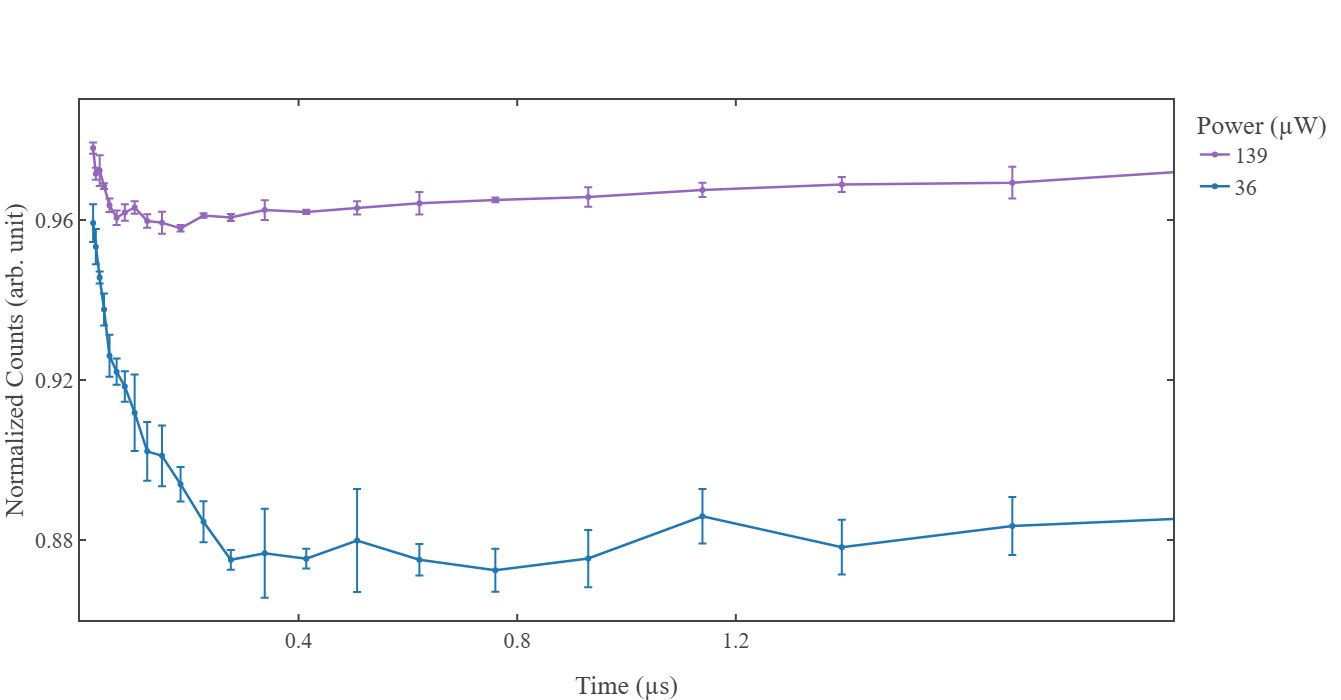


Processing: bigger cluster


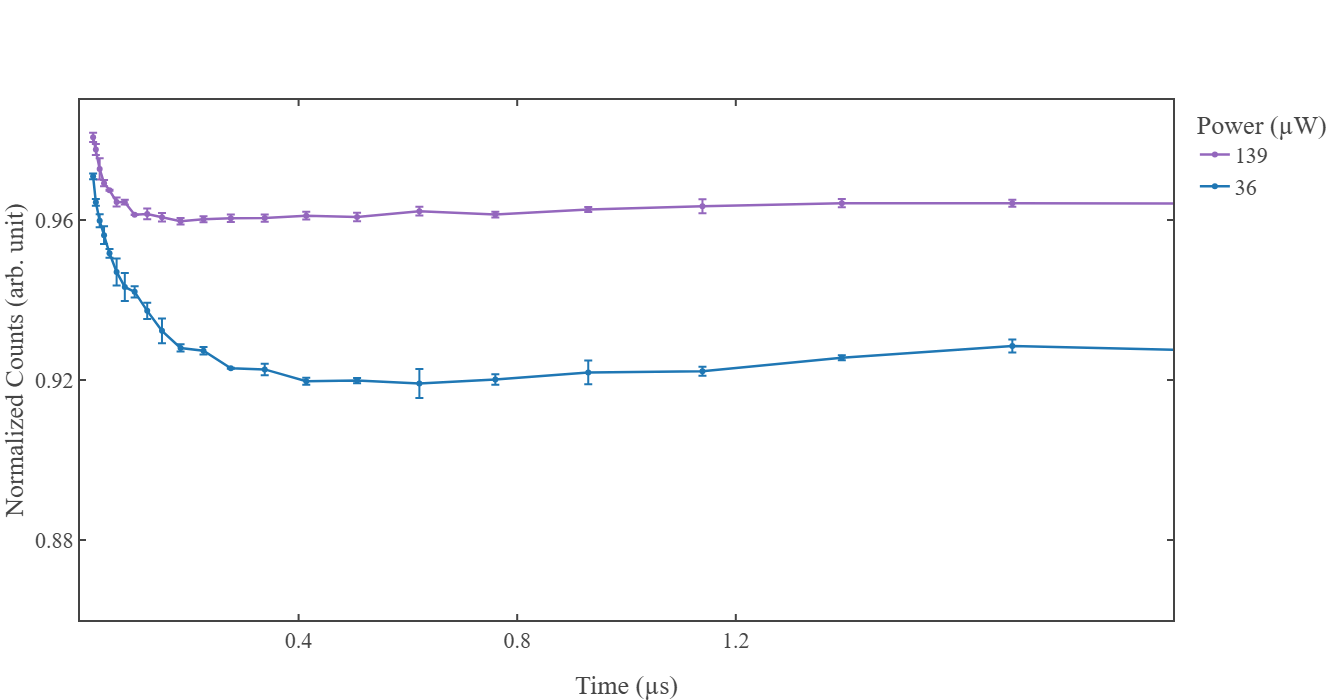


Processing: small cluster


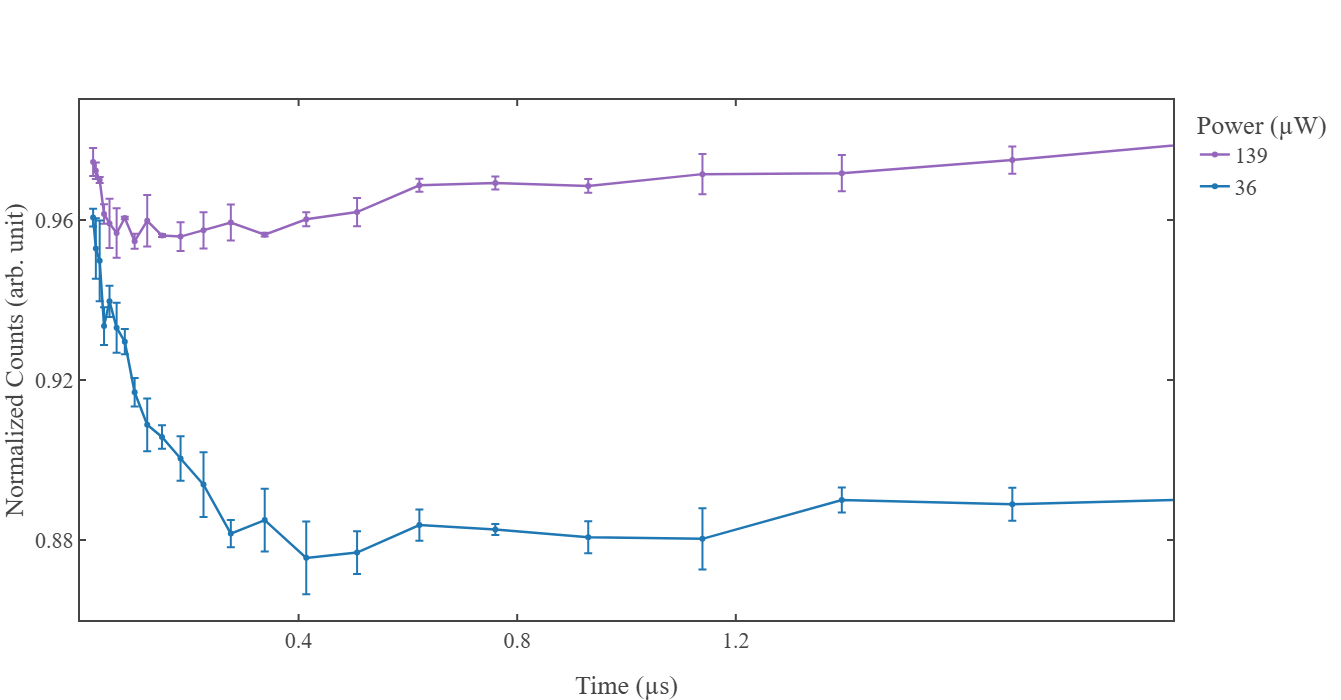

In [12]:
import os
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio  # Required for saving as PNG

# ============================================================
# --- Signal Processing Functions ---
# ============================================================
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# ============================================================
# --- Plotly Template & Calibration ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

# --- Calibration Dictionary (source mW → sample µW) ---
calibration = {
    1: 13,
    3: 36,
    4: 47,
    5: 64,
    7: 79,
    9: 104,
    11: 139,
    13: 167,
    15: 191,
    17: 209,
    18: 221
}

# ============================================================
# --- Paths and Parameters ---
# ============================================================
samples = 2000
# Updated base path for citric acid
base_folder_root = r"D:\Atanu\Atanu_Github\T1_measurements\codes\data\2025\Oct_10\citric acid\0.1 mol"
pulse_folder = "l_50.0us"
systematic_path = r"systematic\a_5\s_2000"

# Updated cluster folders
cluster_folders = ['big cluster', 'bigger cluster', 'small cluster']
power_folders = ['p_11mW', 'p_3mW']

# --- Define Output Folder ---
output_fig_folder = r"D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper"
os.makedirs(output_fig_folder, exist_ok=True)

# --- Define Consistent Colors ---
color_map = {
    'p_3mW': '#1f77b4',  # Muted Blue
    'p_4mW': '#ff7f0e',  # Safety Orange
    'p_5mW': '#2ca02c',  # Cooked Asparagus Green
    'p_9mW': '#d62728',  # Brick Red
    'p_11mW': '#9467bd', # Muted Purple
    'p_18mW': '#8c564b'  # Chestnut Brown
}

# ============================================================
# --- Data Processing & Plotting Loop ---
# ============================================================
for cluster_name in cluster_folders:
    print(f"\nProcessing: {cluster_name}")
    
    # --- Initialize a new figure for each cluster ---
    fig = go.Figure()

    for power_folder in power_folders:
        try:
            source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
        except (IndexError, ValueError):
            print(f"Could not extract power from folder name: {power_folder}")
            continue

        sample_power_uW = calibration.get(source_power_mW, None)
        if sample_power_uW is None:
            print(f"No calibration available for {source_power_mW} mW. Skipping.")
            continue

        cluster_path = os.path.join(base_folder_root, cluster_name)
        folder_path = os.path.join(cluster_path, power_folder, pulse_folder, systematic_path)
        if not os.path.exists(folder_path):
            print(f"Folder does not exist: {folder_path}")
            continue

        npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
        if len(npz_files) < 3:
            print(f"Less than 3 datasets found in {folder_path}. Skipping.")
            continue

        signal_photon_list = []
        time_axis = None

        for npz_file in npz_files[:3]:
            npz_path = os.path.join(folder_path, npz_file)
            data = dict(np.load(npz_path))
            time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
            signal_photon_list.append(signal_photon[1:])  # Skip first point

        signal_array = np.vstack(signal_photon_list)
        mean_signal = np.mean(signal_array, axis=0)
        std_signal = np.std(signal_array, axis=0)

        trace_color = color_map.get(power_folder, '#000000')

        fig.add_trace(go.Scatter(
            x=time_axis[1:] / 1e3,  # Convert to µs
            y=mean_signal,
            mode='markers+lines',
            name=f'{sample_power_uW}',
            line=dict(width=2.5, color=trace_color),
            marker=dict(size=6, color=trace_color),
            error_y=dict(
                type='data',
                array=std_signal,
                visible=True,
                color=trace_color
            )
        ))

    # --- Final Plot Layout ---
    fig.update_layout(
        template=fig_template,
        xaxis_title='Time (µs)',
        yaxis_title='Normalized Counts (arb. unit)',
        legend_title='Power (µW)',
        width=800,
        height=700,
        xaxis=dict(
            # range=[-10, 410],
            # tickvals=[0, 100, 200, 300, 400],
            range=[0, 2.0],
            tickvals=[0.4,0.8,1.2],
        ),  
        yaxis=dict(
            # range=[0.8, 1.12],
            # tickvals=[0.7, 0.8, 0.9, 1.0,1.1],
            range=[0.86, 0.99],
            tickvals=[0.88,0.92,0.96],
        )
    )

    # --- Show Plot ---
    fig.show()

    # # --- Save High-Resolution PNG ---
    # safe_cluster_name = cluster_name.replace(" ", "_").lower()
    
    # # Prepending "citric_acid_" to avoid overwriting your earlier plots
    # out_path = os.path.join(output_fig_folder, f"citric_acid_{safe_cluster_name}_power_dependency_zoomed_in.png")
    
    # pio.write_image(
    #     fig, 
    #     out_path, 
    #     width=800, 
    #     height=700, 
    #     scale=4
    # )
    # print(f"Saved figure: {out_path}")


Processing: big cluster

Processing: bigger cluster

Processing: small cluster


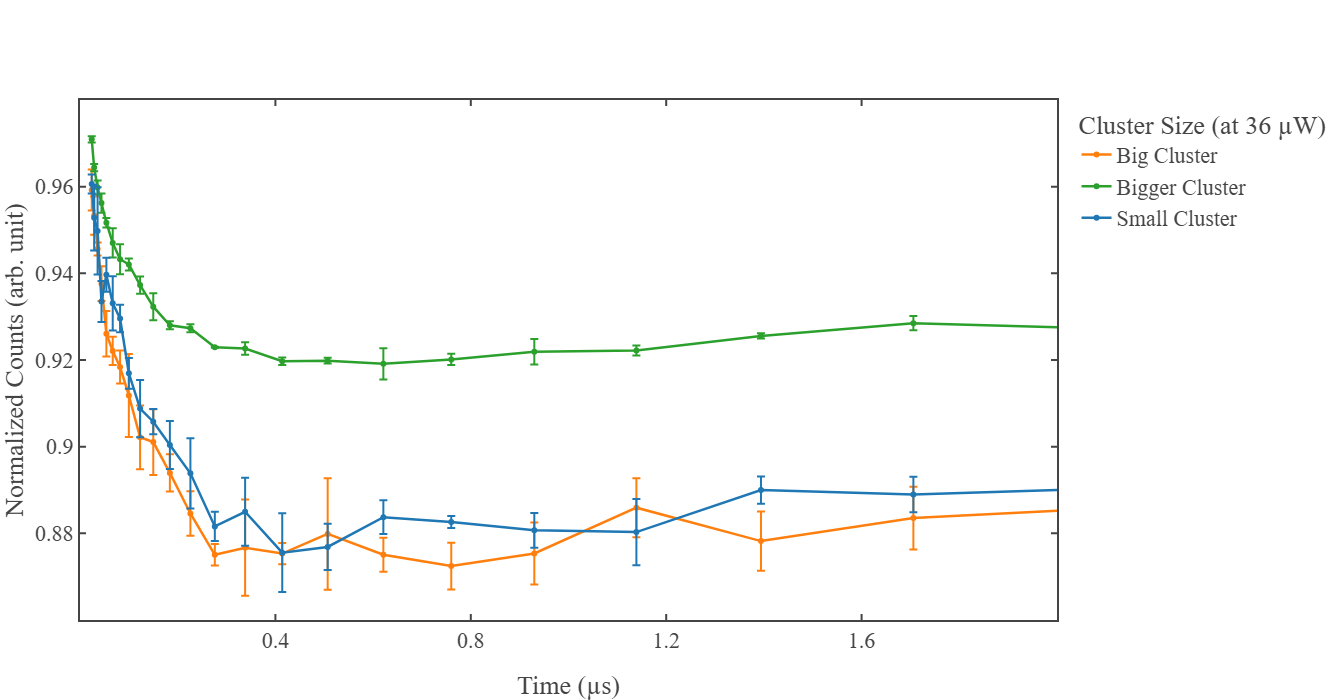

Saved figure: D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper\citric_acid_all_clusters_36uW_zoomed_in.png


In [21]:
import os
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio  # Required for saving as PNG

# ============================================================
# --- Signal Processing Functions ---
# ============================================================
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# ============================================================
# --- Plotly Template & Calibration ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

# --- Calibration Dictionary (source mW → sample µW) ---
calibration = {
    1: 13,
    3: 36,
    4: 47,
    5: 64,
    7: 79,
    9: 104,
    11: 139,
    13: 167,
    15: 191,
    17: 209,
    18: 221
}

# ============================================================
# --- Paths and Parameters ---
# ============================================================
samples = 2000
# Updated base path for citric acid
base_folder_root = r"D:\Atanu\Atanu_Github\T1_measurements\codes\data\2025\Oct_10\citric acid\0.1 mol"
pulse_folder = "l_50.0us"
systematic_path = r"systematic\a_5\s_2000"

# Updated cluster folders
cluster_folders = ['big cluster', 'bigger cluster', 'small cluster']

# MODIFICATION: Only process the 3mW folder (which equals 36 uW)
power_folders = ['p_3mW']

# --- Define Output Folder ---
output_fig_folder = r"D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper"
os.makedirs(output_fig_folder, exist_ok=True)

# MODIFICATION: Define Consistent Colors for clusters instead of power
cluster_color_map = {
    'small cluster': '#1f77b4',   # Muted Blue
    'big cluster': '#ff7f0e',     # Safety Orange
    'bigger cluster': '#2ca02c'   # Cooked Asparagus Green
}

# ============================================================
# --- Data Processing & Plotting Loop ---
# ============================================================

# MODIFICATION: Initialize a SINGLE figure before the loops to plot all clusters together
fig = go.Figure()

for cluster_name in cluster_folders:
    print(f"\nProcessing: {cluster_name}")
    
    for power_folder in power_folders:
        try:
            source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
        except (IndexError, ValueError):
            print(f"Could not extract power from folder name: {power_folder}")
            continue

        sample_power_uW = calibration.get(source_power_mW, None)
        if sample_power_uW is None:
            print(f"No calibration available for {source_power_mW} mW. Skipping.")
            continue

        cluster_path = os.path.join(base_folder_root, cluster_name)
        folder_path = os.path.join(cluster_path, power_folder, pulse_folder, systematic_path)
        if not os.path.exists(folder_path):
            print(f"Folder does not exist: {folder_path}")
            continue

        npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
        if len(npz_files) < 3:
            print(f"Less than 3 datasets found in {folder_path}. Skipping.")
            continue

        signal_photon_list = []
        time_axis = None

        for npz_file in npz_files[:3]:
            npz_path = os.path.join(folder_path, npz_file)
            data = dict(np.load(npz_path))
            time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
            signal_photon_list.append(signal_photon[1:])  # Skip first point

        signal_array = np.vstack(signal_photon_list)
        mean_signal = np.mean(signal_array, axis=0)
        std_signal = np.std(signal_array, axis=0)

        # Map the color to the cluster type
        trace_color = cluster_color_map.get(cluster_name, '#000000')

        # Add trace for the current cluster
        fig.add_trace(go.Scatter(
            x=time_axis[1:] / 1e3,  # Convert to µs
            y=mean_signal,
            mode='markers+lines',
            name=f'{cluster_name.title()}', # Change legend name to cluster name
            line=dict(width=2.5, color=trace_color),
            marker=dict(size=6, color=trace_color),
            error_y=dict(
                type='data',
                array=std_signal,
                visible=True,
                color=trace_color
            ),
            # showlegend = False,
        ))

# ============================================================
# --- Final Plot Layout & Rendering ---
# ============================================================
# MODIFICATION: Placed outside the loop to render once after all clusters are added
fig.update_layout(
    template=fig_template,
    xaxis_title='Time (µs)',
    yaxis_title='Normalized Counts (arb. unit)',
    legend_title=f'Cluster Size (at {sample_power_uW} µW)',
    width=900,
    height=700,
    xaxis=dict(
        range=[0, 2.0],
        tickvals=[0.4, 0.8, 1.2,1.6],
    ),  
    yaxis=dict(
        range=[0.86, 0.98],
        tickvals=[ 0.88, 0.90,0.92, 0.94, 0.96],
    )
)

# --- Show Plot ---
fig.show()

# --- Save High-Resolution PNG ---
# Updated filename to reflect all clusters at a single power
out_path = os.path.join(output_fig_folder, f"citric_acid_all_clusters_{sample_power_uW}uW_zoomed_in.png")

pio.write_image(
    fig, 
    out_path, 
    width=900, 
    height=700, 
    scale=4
)
print(f"Saved figure: {out_path}")


Processing Power: p_3mW
  -> Adding concentration: 1 mol (big cluster)
  -> Adding concentration: 0.1 mol (big cluster)
  -> Adding concentration: 0.01 mol (big cluster)


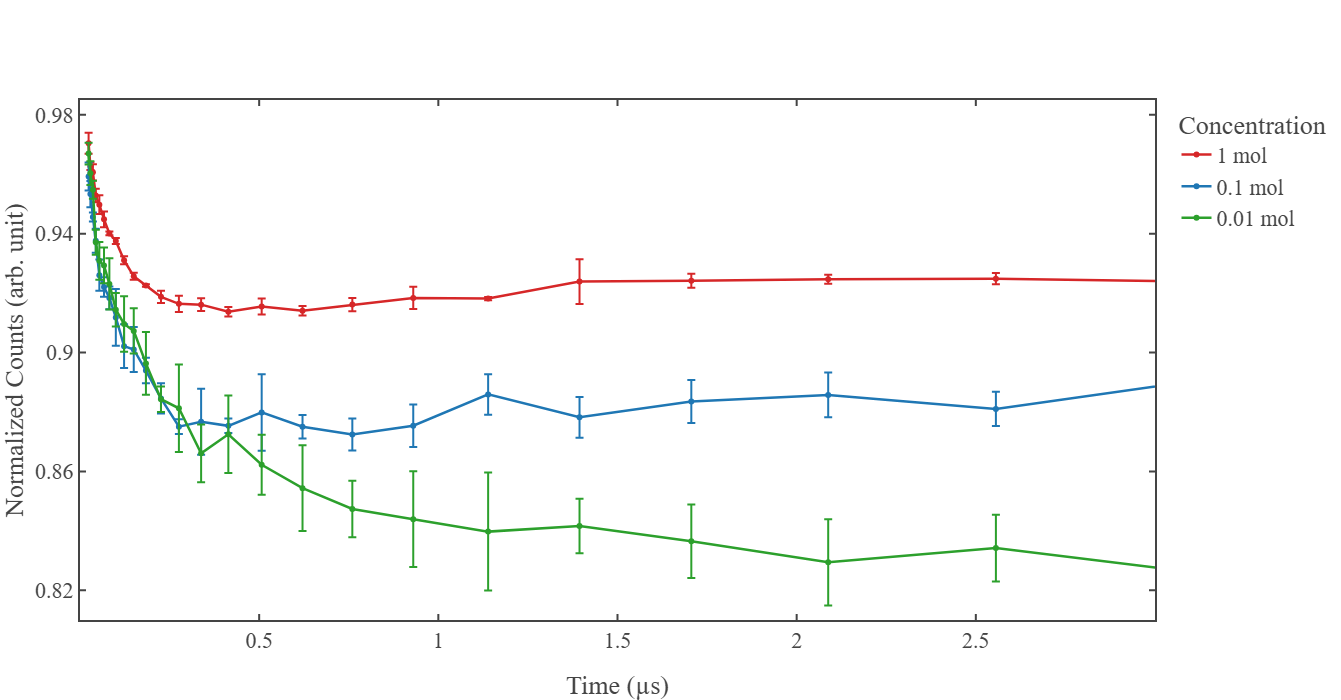

Saved figure: D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper\citric_acid_big_cluster_p_3mW_comparison.png

Processing Power: p_11mW
  -> Adding concentration: 1 mol (big cluster)
  -> Adding concentration: 0.1 mol (big cluster)
  -> Adding concentration: 0.01 mol (big cluster)


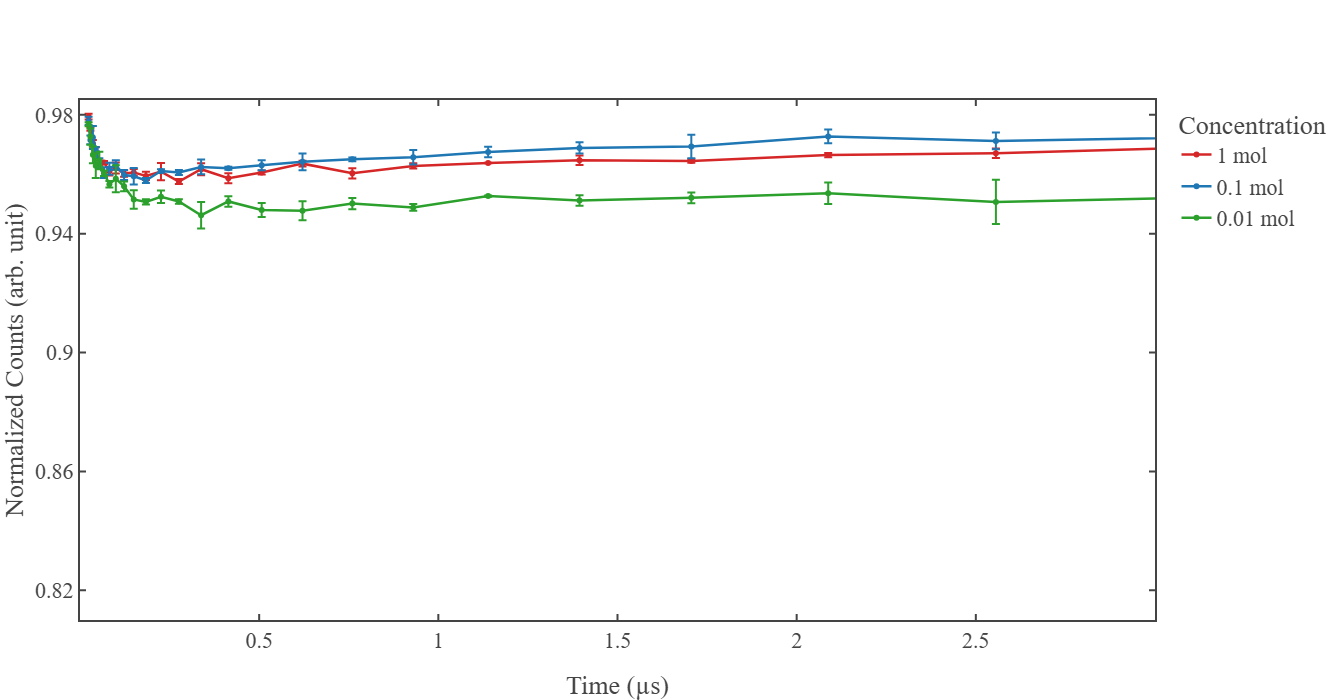

In [35]:
import os
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio  # Required for saving as PNG

# ============================================================
# --- Signal Processing Functions ---
# ============================================================
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# ============================================================
# --- Plotly Template & Calibration ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

calibration = {
    1: 13, 3: 36, 4: 47, 5: 64, 7: 79,
    9: 104, 11: 139, 13: 167, 15: 191,
    17: 209, 18: 221
}

# ============================================================
# --- Paths and Parameters ---
# ============================================================
samples = 2000
base_folder_root = r"D:\Atanu\Atanu_Github\T1_measurements\codes\data\2025\Oct_10\citric acid"
pulse_folder = "l_50.0us"
systematic_path = r"systematic\a_5\s_2000"

concentrations = ['1 mol', '0.1 mol', '0.01 mol']
power_folders = ['p_3mW', 'p_11mW']

# --- NEW: Target specific cluster inside each concentration ---
target_cluster = 'big cluster' 

# --- Define Output Folder ---
output_fig_folder = r"D:\Atanu\Atanu_Github\T1_measurements\codes\figures_in_paper"
os.makedirs(output_fig_folder, exist_ok=True)

# --- Define Consistent Colors for Concentrations ---
concentration_color_map = {
    '1 mol': '#d62728',     # Brick Red
    '0.1 mol': '#1f77b4',   # Muted Blue
    '0.01 mol': '#2ca02c',  # Cooked Asparagus Green
}

# ============================================================
# --- Data Processing & Plotting Loop ---
# ============================================================
for power_folder in power_folders:
    print(f"\nProcessing Power: {power_folder}")
    
    try:
        source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
        sample_power_uW = calibration.get(source_power_mW, "Unknown")
    except (IndexError, ValueError):
        source_power_mW = power_folder
        sample_power_uW = "Unknown"

    fig = go.Figure()

    for concentration in concentrations:
        print(f"  -> Adding concentration: {concentration} ({target_cluster})")
        
        # --- PATH UPDATE: Injected target_cluster between concentration and power ---
        folder_path = os.path.join(base_folder_root, concentration, target_cluster, power_folder, pulse_folder, systematic_path)
        
        if not os.path.exists(folder_path):
            print(f"     [❌] Folder does not exist: {folder_path}")
            continue

        npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
        if len(npz_files) < 3:
            print(f"     [⚠️] Less than 3 datasets found. Skipping.")
            continue

        signal_photon_list = []
        time_axis = None

        for npz_file in npz_files[:3]:
            npz_path = os.path.join(folder_path, npz_file)
            data = dict(np.load(npz_path))
            time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
            signal_photon_list.append(signal_photon[1:])  

        signal_array = np.vstack(signal_photon_list)
        mean_signal = np.mean(signal_array, axis=0)
        std_signal = np.std(signal_array, axis=0)

        trace_color = concentration_color_map.get(concentration, '#000000')

        fig.add_trace(go.Scatter(
            x=time_axis[1:] / 1e3,  # Convert to µs
            y=mean_signal,
            mode='markers+lines',
            name=f'{concentration}',
            line=dict(width=2.5, color=trace_color),
            marker=dict(size=6, color=trace_color),
            error_y=dict(
                type='data',
                array=std_signal,
                visible=True,
                color=trace_color
            )
        ))

    # --- Final Plot Layout ---
    fig.update_layout(
        template=fig_template,
        # title=f"Citric Acid ({target_cluster.title()}) Comparison @ {sample_power_uW} µW",
        xaxis_title='Time (µs)',
        yaxis_title='Normalized Counts (arb. unit)',
        legend_title='Concentration',
        width=850,
        height=700,
        xaxis=dict(
            # range=[-10, 410],
            # tickvals=[0, 100, 200, 300, 400],
            range=[0, 3.0],
            tickvals=[0.5,1.0,1.5,2.0,2.5],
        ),  
        yaxis=dict(
            # range=[0.91, 1.03],
            # tickvals=[0.92,0.94,0.96,0.98,1.0,1.02],
            range=[0.81, 0.985],
            tickvals=[0.82,0.86,0.90,0.94,0.98],
        )
    )

    # --- Show Plot ---
    fig.show()

    if sample_power_uW == 36:
        # --- Save High-Resolution PNG ---
        safe_cluster_name = target_cluster.replace(" ", "_").lower()
        out_path = os.path.join(output_fig_folder, f"citric_acid_{safe_cluster_name}_{power_folder}_comparison.png")
        
        pio.write_image(
            fig, 
            out_path, 
            width=850, 
            height=700, 
            scale=4
        )
        print(f"Saved figure: {out_path}")